In [19]:
#п1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('athletes.csv')
df.head()

,id,name,nationality,sex,dob,height,weight,sport,gold,silver,bronze
0,736041664,A Jesus Garcia,ESP,male,10/17/69,1.72,64.0,athletics,0,0,0
1,532037425,A Lam Shin,KOR,female,9/23/86,1.68,56.0,fencing,0,0,0
2,435962603,Aaron Brown,CAN,male,5/27/92,1.98,79.0,athletics,0,0,1
3,521041435,Aaron Cook,MDA,male,1/2/91,1.83,80.0,taekwondo,0,0,0
4,33922579,Aaron Gate,NZL,male,11/26/90,1.81,71.0,cycling,0,0,0


In [2]:
df.info()
print("\nпропуски")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11538 entries, 0 to 11537
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           11538 non-null  int64  
 1   name         11538 non-null  object 
 2   nationality  11538 non-null  object 
 3   sex          11538 non-null  object 
 4   dob          11537 non-null  object 
 5   height       11208 non-null  float64
 6   weight       10879 non-null  float64
 7   sport        11538 non-null  object 
 8   gold         11538 non-null  int64  
 9   silver       11538 non-null  int64  
 10  bronze       11538 non-null  int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 991.7+ KB

пропуски
id               0
name             0
nationality      0
sex              0
dob              1
height         330
weight         659
sport            0
gold             0
silver           0
bronze           0
dtype: int64


In [3]:
df = df.drop(['id', 'name', 'dob'], axis=1)
print(df.columns.tolist())

['nationality', 'sex', 'height', 'weight', 'sport', 'gold', 'silver', 'bronze']


In [4]:
df = df.dropna()
print(df.isnull().sum())

nationality    0
sex            0
height         0
weight         0
sport          0
gold           0
silver         0
bronze         0
dtype: int64


In [5]:
from sklearn.preprocessing import LabelEncoder
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

In [6]:
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
print(df.dtypes)

nationality      int64
sex              int64
height         float64
weight         float64
sport            int64
gold             int64
silver           int64
bronze           int64
dtype: object


In [20]:
#п2
X = df.drop('sex', axis=1)
Y = df['sex']

print(f"X: {X.shape}")
print(f"Y: {Y.shape}")
print(f"Распределение классов в Y:\n{Y.value_counts()}")

X: (11538, 10)
Y: (11538,)
Распределение классов в Y:
sex
male      6333
female    5205
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

print(f"Размер обучающей модели: {X_train.shape}")
print(f"Размер тестовой модели: {X_test.shape}")

Размер обучающей модели: (8686, 7)
Размер тестовой модели: (2172, 7)


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Масштабирование выполнено")
print(f"Тип X_train после масштабирования: {type(X_train)}")
print(f"Форма X_train: {X_train.shape}")

Масштабирование выполнено
Тип X_train после масштабирования: <class 'numpy.ndarray'>
Форма X_train: (8686, 7)


In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, Y_train)

print("Модель обучена")

Модель обучена


In [11]:
y_pred_proba = model.predict_proba(X_test)[:, 1]

print(f"\n{y_pred_proba[:5]}")
print(f"{y_pred_proba.shape}")


[0.88739735 0.39484211 0.07452237 0.37722906 0.37268479]
(2172,)


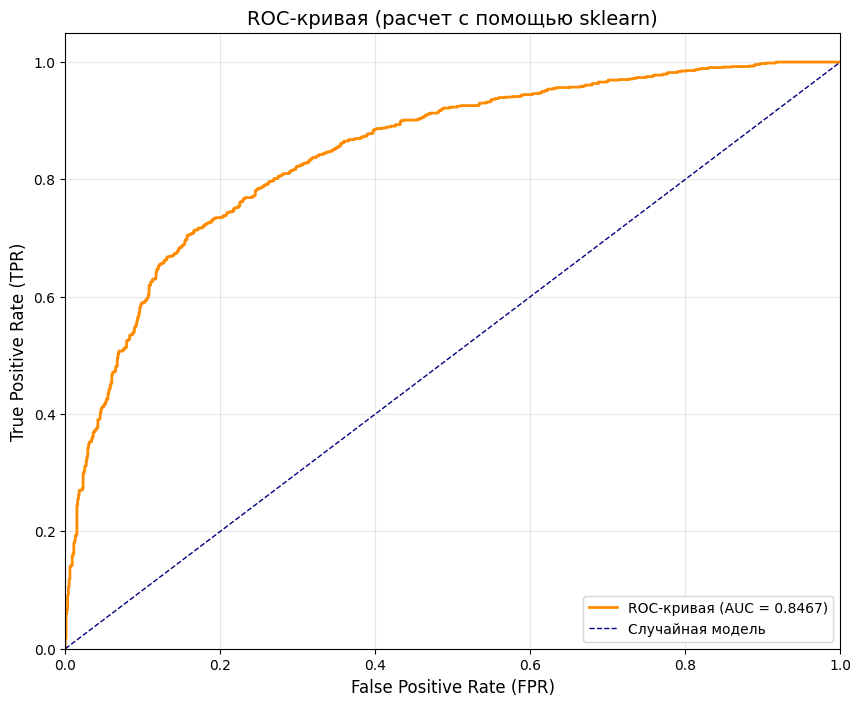

In [25]:
#п3
from sklearn.metrics import roc_curve, roc_auc_score

fpr_sklearn, tpr_sklearn, thresholds_sklearn = roc_curve(Y_test, y_pred_proba)

plt.figure(figsize=(10, 8))
plt.plot(fpr_sklearn, tpr_sklearn, color='darkorange', lw=2, 
         label=f'ROC-кривая (AUC = {roc_auc_sklearn:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', 
         label='Случайная модель')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC-кривая (расчет с помощью sklearn)', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
#п.4
roc_auc_sklearn = roc_auc_score(Y_test, y_pred_proba)
print(f"ROC-AUC (sklearn): {roc_auc_sklearn:.4f}")

ROC-AUC (sklearn): 0.8467


In [28]:
#п5
thresholds_manual = np.unique(y_pred_proba)
thresholds_manual = np.sort(np.append(thresholds_manual, [0, 1]))

tpr_manual = []
fpr_manual = []

for thresh in thresholds_manual:
    y_pred = (y_pred_proba >= thresh).astype(int)
    
    from sklearn.metrics import confusion_matrix
    tn, fp, fn, tp = confusion_matrix(Y_test, y_pred).ravel()
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    tpr_manual.append(tpr)
    fpr_manual.append(fpr)

tpr_manual = np.array(tpr_manual)
fpr_manual = np.array(fpr_manual)

print(f"пороги: {len(thresholds_manual)}")
print(f"первые 5 порогов:")
for i in range(min(5, len(thresholds_manual))):
    print(f"Порог: {thresholds_manual[i]:.4f}, TPR: {tpr_manual[i]:.4f}, FPR: {fpr_manual[i]:.4f}")

пороги: 2165
первые 5 порогов:
Порог: 0.0000, TPR: 1.0000, FPR: 1.0000
Порог: 0.0029, TPR: 1.0000, FPR: 1.0000
Порог: 0.0035, TPR: 1.0000, FPR: 0.9990
Порог: 0.0041, TPR: 1.0000, FPR: 0.9980
Порог: 0.0043, TPR: 1.0000, FPR: 0.9970


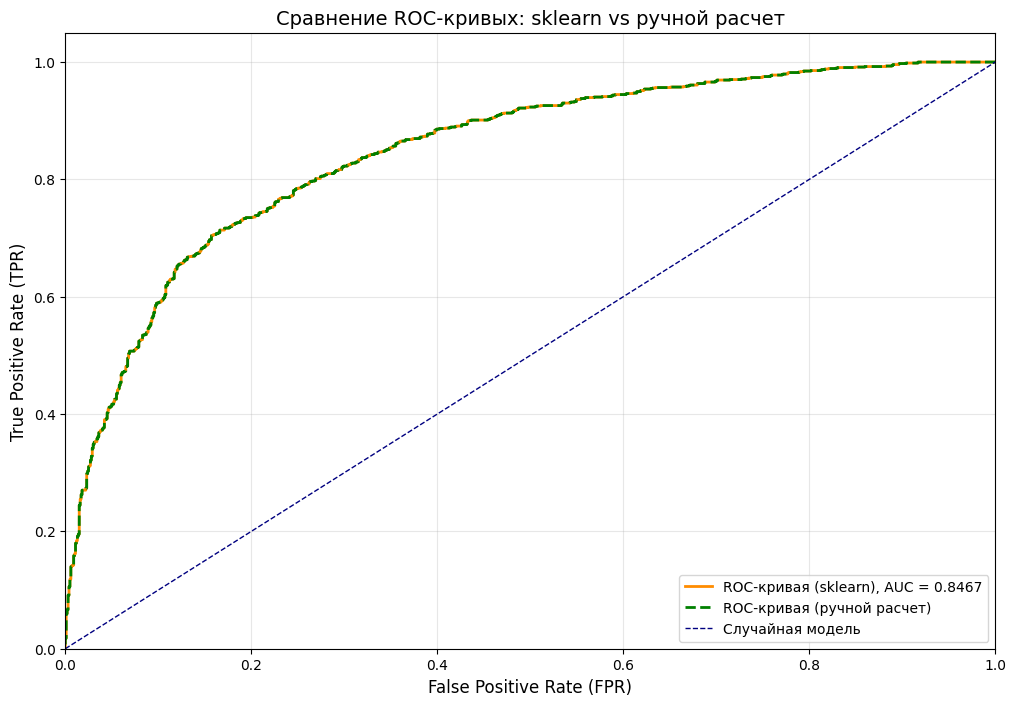

In [29]:
#п6
plt.figure(figsize=(12, 8))

#sklearn
plt.plot(fpr_sklearn, tpr_sklearn, color='darkorange', lw=2, 
         label=f'ROC-кривая (sklearn), AUC = {roc_auc_sklearn:.4f}')
#руками
plt.plot(fpr_manual, tpr_manual, color='green', lw=2, linestyle='--', 
         label='ROC-кривая (ручной расчет)')

plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', 
         label='Случайная модель')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Сравнение ROC-кривых: sklearn vs ручной расчет', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

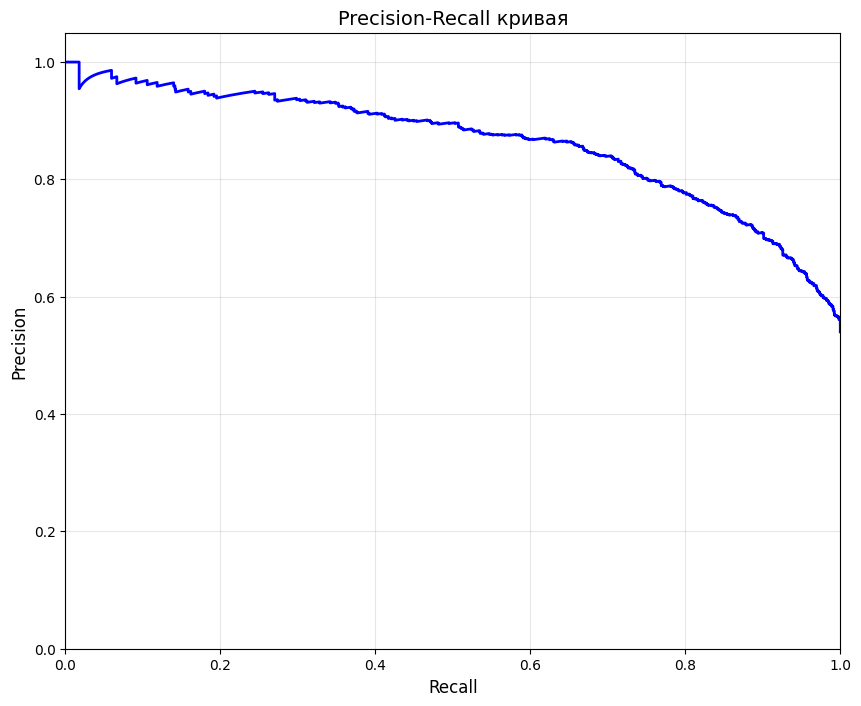

In [30]:
#п7
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(Y_test, y_pred_proba)

plt.figure(figsize=(10, 8))
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall кривая', fontsize=14)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
#п.8
sorted_indices = np.argsort(fpr_manual)
fpr_sorted = fpr_manual[sorted_indices]
tpr_sorted = tpr_manual[sorted_indices]

roc_auc_manual = np.trapz(tpr_sorted, fpr_sorted)

print(f"ROC-AUC (sklearn): {roc_auc_sklearn:.4f}")
print(f"ROC-AUC (ручной расчет): {roc_auc_manual:.4f}")
print(f"Разница: {abs(roc_auc_sklearn - roc_auc_manual):.10f}")

ROC-AUC (sklearn): 0.8467
ROC-AUC (ручной расчет): 0.8466
Разница: 0.0000473619


In [18]:
print("ВЫВОДЫ ПО ПРОДЕЛАННОЙ РАБОТЕ")
print(f"""
По ROC-кривой видно, что модель лучше случайного угадывания. Чем ближе кривая к левому верхнему углу, тем лучше модель.
ROC-кривая МОЖЕТ проходить ниже диагонали. Это означает, что модель работает хуже случайного угадывания (AUC < 0.5).
В таком случае можно инвертировать предсказания.
""")


ВЫВОДЫ ПО ПРОДЕЛАННОЙ РАБОТЕ

По ROC-кривой видно, что модель лучше случайного угадывания. Чем ближе кривая к левому верхнему углу, тем лучше модель.
ROC-кривая МОЖЕТ проходить ниже диагонали. Это означает, что модель работает хуже случайного угадывания (AUC < 0.5).
В таком случае можно инвертировать предсказания.

